<a href="https://colab.research.google.com/github/partha-pkp/data-mining-drug-discovery/blob/main/partha/final_6380_analysis_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cell 1 — imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    f1_score
)

In [ ]:
import sklearn
print(sklearn.__version__)


1.8.0


In [ ]:
#  if not 1.8.0

# !pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 77.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


# Cell 2 — load the two exported datasets

In [ ]:
df_norm = pd.read_csv("data_norm.csv")
df_selected = pd.read_csv("df_selected_CFS17.csv")

print("df_norm shape:", df_norm.shape)
print("df_selected shape:", df_selected.shape)

df_norm shape: (4866, 201)
df_selected shape: (4866, 18)


Cell 3 — clean the datasets

In [ ]:
target_col = "senolytic"

def clean_exported_df(df, target_col="senolytic"):
    df = df.copy()
    df = df.replace("?", np.nan)

    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=[target_col]).copy()
    df[target_col] = df[target_col].astype(int)
    return df

df_norm = clean_exported_df(df_norm, target_col=target_col)
df_selected = clean_exported_df(df_selected, target_col=target_col)

X_all = df_norm.drop(columns=[target_col]).copy()
X_fs = df_selected.drop(columns=[target_col]).copy()
y = df_norm[target_col].reset_index(drop=True).copy()

print("All features:", X_all.shape)
print("FS features:", X_fs.shape)
print(y.value_counts())
print("Positive rate:", y.mean())

All features: (4866, 200)
FS features: (4866, 17)
senolytic
0    4763
1     103
Name: count, dtype: int64
Positive rate: 0.02116728318947801


Cell 4 — helper functions

In [ ]:
def make_bagging_model(n_estimators=100, max_depth=None, min_samples_leaf=1):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", BaggingClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            ),
            n_estimators=n_estimators,
            bootstrap=True,
            max_samples=1.0,
            random_state=42,
            n_jobs=-1
        ))
    ])


def make_mlp_model(hidden_layer_sizes=(64,), alpha=0.0001, learning_rate_init=0.0005):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            alpha=alpha,
            learning_rate_init=learning_rate_init,
            max_iter=400,
            early_stopping=True,
            random_state=42
        ))
    ])


def resample_by_class_weight(X, y, pos_weight=5, random_state=42):
    rng = np.random.default_rng(random_state)

    X = pd.DataFrame(X).reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)

    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]

    if len(pos_idx) == 0:
        return X, y

    extra_pos = rng.choice(
        pos_idx,
        size=max(0, int(pos_weight) - 1) * len(pos_idx),
        replace=True
    )

    new_idx = np.concatenate([neg_idx, pos_idx, extra_pos])
    rng.shuffle(new_idx)

    X_new = X.iloc[new_idx].reset_index(drop=True)
    y_new = y.iloc[new_idx].reset_index(drop=True)

    return X_new, y_new

Cell 5 — choose threshold from the PR curve

In [ ]:
def choose_threshold_from_pr(y_true, y_prob, target_recall=0.60):
    thresholds = np.linspace(0, 1, 1001)

    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        rows.append((t, p, r, f1))

    curve_df = pd.DataFrame(rows, columns=["threshold", "precision", "recall", "f1"])

    good = curve_df[curve_df["recall"] >= target_recall].copy()

    if len(good) > 0:
        best = good.sort_values(
            ["precision", "recall", "f1", "threshold"],
            ascending=[False, False, False, False]
        ).iloc[0]
        rule = f"max precision subject to recall >= {target_recall}"
    else:
        best = curve_df.sort_values(
            ["f1", "precision", "recall"],
            ascending=[False, False, False]
        ).iloc[0]
        rule = "fallback to best F1 (target recall not reached)"

    return {
        "threshold": float(best["threshold"]),
        "precision": float(best["precision"]),
        "recall": float(best["recall"]),
        "f1": float(best["f1"]),
        "rule": rule,
        "curve_df": curve_df
    }

Cell 6 — CV evaluator for one candidate config

In [ ]:
def evaluate_candidate_cv(X, y, family, model_params, pos_weight,
                          target_recall=0.60, n_splits=10, random_state=42):
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_prob = np.zeros(len(y), dtype=float)

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]
        y_train = y.iloc[train_idx]

        if family == "bagging":
            model = make_bagging_model(**model_params)

            sample_w = np.where(y_train == 1, pos_weight, 1.0)
            model.fit(X_train, y_train, model__sample_weight=sample_w)

        elif family == "mlp":
            model = make_mlp_model(**model_params)

            X_train_res, y_train_res = resample_by_class_weight(
                X_train, y_train,
                pos_weight=pos_weight,
                random_state=random_state + fold
            )
            model.fit(X_train_res, y_train_res)

        else:
            raise ValueError("family must be 'bagging' or 'mlp'")

        oof_prob[valid_idx] = model.predict_proba(X_valid)[:, 1]

    threshold_info = choose_threshold_from_pr(
        y_true=y,
        y_prob=oof_prob,
        target_recall=target_recall
    )

    chosen_t = threshold_info["threshold"]
    oof_pred = (oof_prob >= chosen_t).astype(int)
    cm = confusion_matrix(y, oof_pred)

    return {
        "family": family,
        "params": model_params,
        "pos_weight": pos_weight,
        "target_recall": target_recall,
        "threshold_rule": threshold_info["rule"],
        "chosen_threshold": chosen_t,
        "precision": threshold_info["precision"],
        "recall": threshold_info["recall"],
        "f1": threshold_info["f1"],
        "average_precision": average_precision_score(y, oof_prob),
        "oof_prob": oof_prob,
        "oof_pred": oof_pred,
        "confusion_matrix": cm
    }

Cell 7 — shortlist of candidate configs

In [ ]:
target_recall = 0.60

candidates = {
    "bagging_all": {
        "X": X_all,
        "family": "bagging",
        "configs": [
            {"params": {"n_estimators": 100, "max_depth": 12, "min_samples_leaf": 2}, "pos_weight": 2},
            {"params": {"n_estimators": 100, "max_depth": 8, "min_samples_leaf": 2}, "pos_weight": 10},
            {"params": {"n_estimators": 100, "max_depth": 8, "min_samples_leaf": 2}, "pos_weight": 100},
        ]
    },

    "bagging_fs": {
        "X": X_fs,
        "family": "bagging",
        "configs": [
            {"params": {"n_estimators": 300, "max_depth": 8, "min_samples_leaf": 1}, "pos_weight": 2},
            {"params": {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 2}, "pos_weight": 1},
            {"params": {"n_estimators": 300, "max_depth": 8, "min_samples_leaf": 2}, "pos_weight": 2},
        ]
    },

    "mlp_all": {
        "X": X_all,
        "family": "mlp",
        "configs": [
            {"params": {"hidden_layer_sizes": (100, 50), "alpha": 0.0001, "learning_rate_init": 0.0005}, "pos_weight": 8},
            {"params": {"hidden_layer_sizes": (64,), "alpha": 0.0001, "learning_rate_init": 0.0005}, "pos_weight": 50},
            {"params": {"hidden_layer_sizes": (64,), "alpha": 0.001, "learning_rate_init": 0.0005}, "pos_weight": 20},
        ]
    },

    "mlp_fs": {
        "X": X_fs,
        "family": "mlp",
        "configs": [
            {"params": {"hidden_layer_sizes": (100, 50), "alpha": 0.0001, "learning_rate_init": 0.0005}, "pos_weight": 15},
            {"params": {"hidden_layer_sizes": (64,), "alpha": 0.001, "learning_rate_init": 0.0005}, "pos_weight": 100},
            {"params": {"hidden_layer_sizes": (64,), "alpha": 0.0001, "learning_rate_init": 0.0005}, "pos_weight": 50},
        ]
    }
}

# Cell 8 — run stratified 10-fold CV for all candidates

In [ ]:
all_results = []

for group_name, group in candidates.items():
    print(f"\nRunning group: {group_name}")

    for i, cfg in enumerate(group["configs"], start=1):
        print(f"  candidate {i}/{len(group['configs'])} ...")
        res = evaluate_candidate_cv(
            X=group["X"],
            y=y,
            family=group["family"],
            model_params=cfg["params"],
            pos_weight=cfg["pos_weight"],
            target_recall=target_recall,
            n_splits=10,
            random_state=42
        )

        res["group"] = group_name
        res["candidate_num"] = i
        all_results.append(res)


Running group: bagging_all
  candidate 1/3 ...
  candidate 2/3 ...
  candidate 3/3 ...

Running group: bagging_fs
  candidate 1/3 ...
  candidate 2/3 ...
  candidate 3/3 ...

Running group: mlp_all
  candidate 1/3 ...
  candidate 2/3 ...
  candidate 3/3 ...

Running group: mlp_fs
  candidate 1/3 ...
  candidate 2/3 ...
  candidate 3/3 ...


Cell 9 — summary of all candidate configs

In [ ]:
summary_df = pd.DataFrame([
    {
        "group": r["group"],
        "candidate_num": r["candidate_num"],
        "family": r["family"],
        "params": str(r["params"]),
        "pos_weight": r["pos_weight"],
        "chosen_threshold": r["chosen_threshold"],
        "threshold_rule": r["threshold_rule"],
        "precision": r["precision"],
        "recall": r["recall"],
        "f1": r["f1"],
        "average_precision": r["average_precision"],
    }
    for r in all_results
])

summary_df = summary_df.sort_values(
    ["group", "precision", "recall", "average_precision"],
    ascending=[True, False, False, False]
).reset_index(drop=True)

summary_df

,group,candidate_num,family,params,pos_weight,chosen_threshold,threshold_rule,precision,recall,f1,average_precision
0,bagging_all,1,bagging,"{'n_estimators': 100, 'max_depth': 12, 'min_sa...",2,0.054,max precision subject to recall >= 0.6,0.093093,0.601942,0.161248,0.194846
1,bagging_all,2,bagging,"{'n_estimators': 100, 'max_depth': 8, 'min_sam...",10,0.085,max precision subject to recall >= 0.6,0.083221,0.601942,0.146226,0.211331
2,bagging_all,3,bagging,"{'n_estimators': 100, 'max_depth': 8, 'min_sam...",100,0.293,max precision subject to recall >= 0.6,0.049363,0.601942,0.091244,0.079949
3,bagging_fs,1,bagging,"{'n_estimators': 300, 'max_depth': 8, 'min_sam...",2,0.045,max precision subject to recall >= 0.6,0.079800,0.621359,0.141436,0.196044
4,bagging_fs,3,bagging,"{'n_estimators': 300, 'max_depth': 8, 'min_sam...",2,0.046,max precision subject to recall >= 0.6,0.076733,0.601942,0.136114,0.193204
5,bagging_fs,2,bagging,"{'n_estimators': 300, 'max_depth': None, 'min_...",1,0.032,max precision subject to recall >= 0.6,0.073897,0.601942,0.131635,0.194755
6,mlp_all,2,mlp,"{'hidden_layer_sizes': (64,), 'alpha': 0.0001,...",50,0.073,max precision subject to recall >= 0.6,0.122772,0.601942,0.203947,0.225718
7,mlp_all,3,mlp,"{'hidden_layer_sizes': (64,), 'alpha': 0.001, ...",20,0.086,max precision subject to recall >= 0.6,0.111913,0.601942,0.188737,0.194779
8,mlp_all,1,mlp,"{'hidden_layer_sizes': (100, 50), 'alpha': 0.0...",8,0.012,max precision subject to recall >= 0.6,0.087201,0.601942,0.152334,0.212576
9,mlp_fs,2,mlp,"{'hidden_layer_sizes': (64,), 'alpha': 0.001, ...",100,0.570,max precision subject to recall >= 0.6,0.093514,0.601942,0.161880,0.188903


Cell 10 — choose the best config in each group

In [ ]:
best_by_group = {}

for group in summary_df["group"].unique():
    top_row = summary_df[summary_df["group"] == group].iloc[0]

    for r in all_results:
        if r["group"] == group and r["candidate_num"] == int(top_row["candidate_num"]):
            best_by_group[group] = r
            break

for group, r in best_by_group.items():
    print("=" * 70)
    print(group)
    print("params:", r["params"])
    print("pos_weight:", r["pos_weight"])
    print("chosen_threshold:", r["chosen_threshold"])
    print("precision:", r["precision"])
    print("recall:", r["recall"])
    print("average_precision:", r["average_precision"])

bagging_all
params: {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 2}
pos_weight: 2
chosen_threshold: 0.054
precision: 0.09309309309309309
recall: 0.6019417475728155
average_precision: 0.19484630722411608
bagging_fs
params: {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 1}
pos_weight: 2
chosen_threshold: 0.045
precision: 0.0798004987531172
recall: 0.6213592233009708
average_precision: 0.19604354272265706
mlp_all
params: {'hidden_layer_sizes': (64,), 'alpha': 0.0001, 'learning_rate_init': 0.0005}
pos_weight: 50
chosen_threshold: 0.073
precision: 0.12277227722772277
recall: 0.6019417475728155
average_precision: 0.22571821649448243
mlp_fs
params: {'hidden_layer_sizes': (64,), 'alpha': 0.001, 'learning_rate_init': 0.0005}
pos_weight: 100
chosen_threshold: 0.5700000000000001
precision: 0.09351432880844646
recall: 0.6019417475728155
average_precision: 0.18890312637721557


# Cell 11 — PR curve for the chosen config in each group

In [ ]:
def plot_pr_with_chosen_point(y_true, y_prob, chosen_threshold, title="PR Curve"):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    y_pred = (y_prob >= chosen_threshold).astype(int)
    p_star = precision_score(y_true, y_pred, zero_division=0)
    r_star = recall_score(y_true, y_pred, zero_division=0)

    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=f"PR curve (AP = {ap:.3f})")
    plt.scatter([r_star], [p_star], s=80, label=f"chosen threshold = {chosen_threshold:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.show()

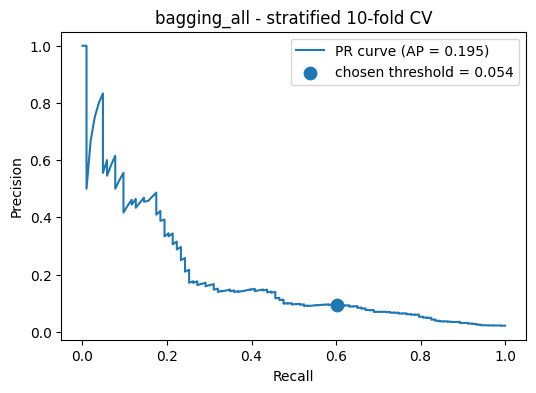

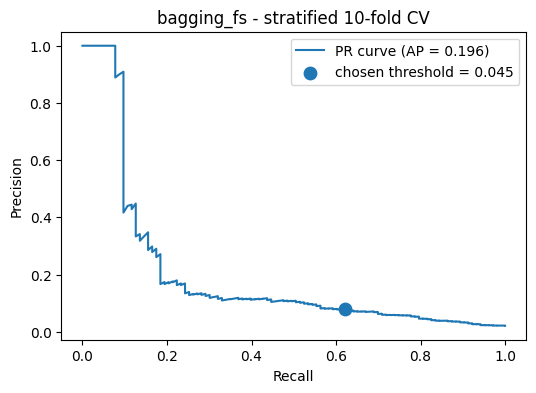

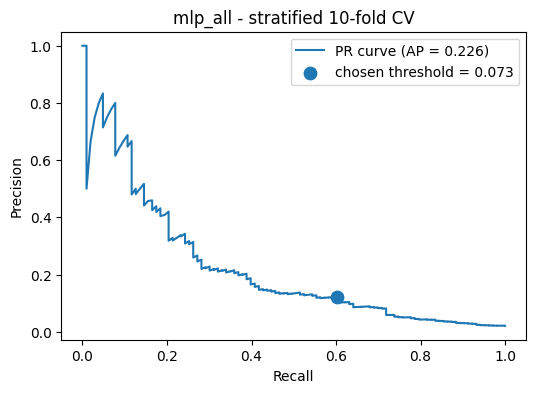

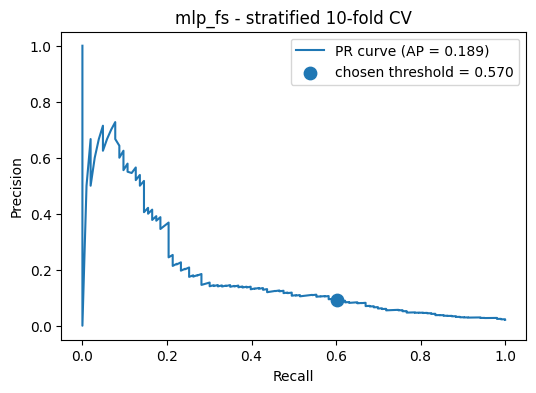

In [ ]:
for group, r in best_by_group.items():
    plot_pr_with_chosen_point(
        y_true=y,
        y_prob=r["oof_prob"],
        chosen_threshold=r["chosen_threshold"],
        title=f"{group} - stratified 10-fold CV"
    )

# Cell 12 — confusion matrix for the chosen config in each group

bagging_all
chosen threshold: 0.054
threshold rule: max precision subject to recall >= 0.6

              precision    recall  f1-score   support

           0      0.990     0.873     0.928      4763
           1      0.093     0.602     0.161       103

    accuracy                          0.867      4866
   macro avg      0.542     0.738     0.545      4866
weighted avg      0.971     0.867     0.912      4866



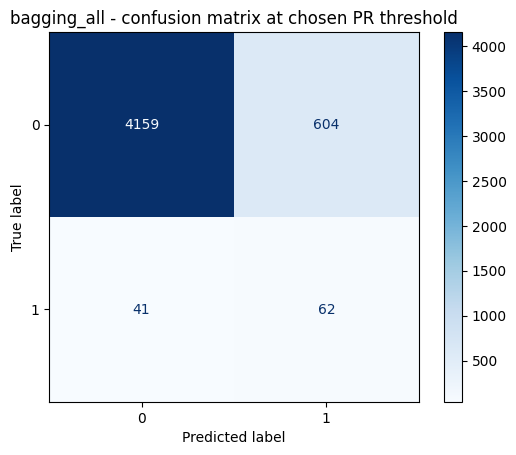

bagging_fs
chosen threshold: 0.045
threshold rule: max precision subject to recall >= 0.6

              precision    recall  f1-score   support

           0      0.990     0.845     0.912      4763
           1      0.080     0.621     0.141       103

    accuracy                          0.840      4866
   macro avg      0.535     0.733     0.527      4866
weighted avg      0.971     0.840     0.896      4866



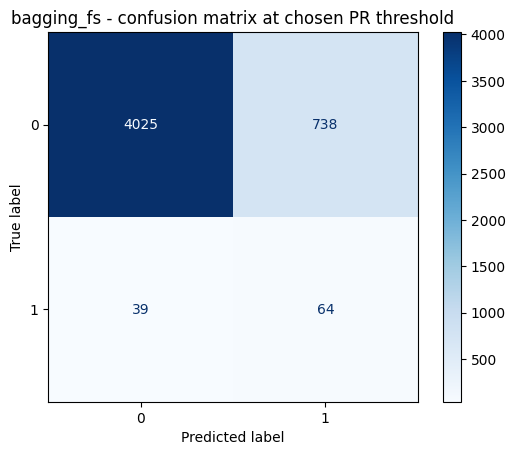

mlp_all
chosen threshold: 0.073
threshold rule: max precision subject to recall >= 0.6

              precision    recall  f1-score   support

           0      0.991     0.907     0.947      4763
           1      0.123     0.602     0.204       103

    accuracy                          0.901      4866
   macro avg      0.557     0.754     0.575      4866
weighted avg      0.972     0.901     0.931      4866



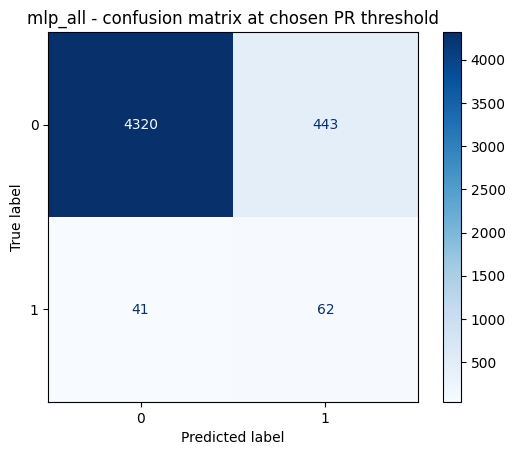

mlp_fs
chosen threshold: 0.5700000000000001
threshold rule: max precision subject to recall >= 0.6

              precision    recall  f1-score   support

           0      0.990     0.874     0.928      4763
           1      0.094     0.602     0.162       103

    accuracy                          0.868      4866
   macro avg      0.542     0.738     0.545      4866
weighted avg      0.971     0.868     0.912      4866



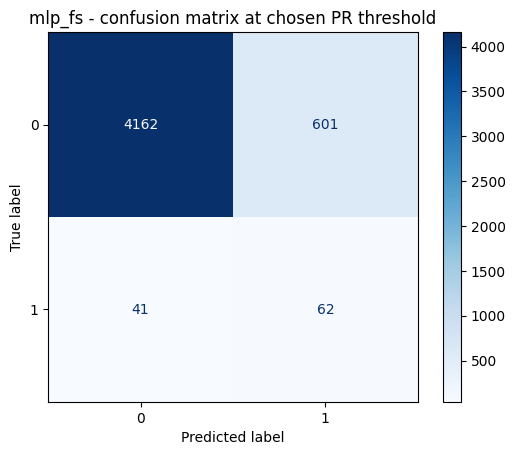

In [ ]:
for group, r in best_by_group.items():
    print("=" * 70)
    print(group)
    print("chosen threshold:", r["chosen_threshold"])
    print("threshold rule:", r["threshold_rule"])
    print()
    print(classification_report(y, r["oof_pred"], digits=3, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(y, r["oof_pred"], cmap="Blues")
    plt.title(f"{group} - confusion matrix at chosen PR threshold")
    plt.show()

In [ ]:
overall_best_group = summary_df.sort_values(
    ["precision", "recall", "average_precision"],
    ascending=[False, False, False]
).iloc[0]["group"]

print("Overall best group:", overall_best_group)
print(best_by_group[overall_best_group]["params"])
print("pos_weight:", best_by_group[overall_best_group]["pos_weight"])
print("threshold:", best_by_group[overall_best_group]["chosen_threshold"])

Overall best group: mlp_all
{'hidden_layer_sizes': (64,), 'alpha': 0.0001, 'learning_rate_init': 0.0005}
pos_weight: 50
threshold: 0.073


save results for later screening

In [ ]:
summary_df.to_csv("cv_candidate_summary.csv", index=False)

for group, r in best_by_group.items():
    pd.DataFrame({
        "y_true": y,
        "oof_prob": r["oof_prob"],
        "oof_pred": r["oof_pred"]
    }).to_csv(f"{group}_best_oof_predictions.csv", index=False)

print("Saved CV results.")

Saved CV results.


# Computational screening

In [ ]:
import numpy as np
import pandas as pd

screening_csv = "list_of_compounds_for_computational_screening.csv"
known21_csv = "ResearchPaperPreds.csv"
smiles_col = "SMILES"
target_col = "senolytic"

screen = pd.read_csv(screening_csv)
known21 = pd.read_csv(known21_csv)

screen[smiles_col] = screen[smiles_col].astype(str).str.strip()
known21[smiles_col] = known21[smiles_col].astype(str).str.strip()

print(screen.shape)
print(known21.shape)
screen.head()

(4340, 203)
(21, 203)


,Name,Library,SMILES,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,qed
0,(-)-Arctigenin,Selleck,COC1=C(O)C=CC(=C1)CC2C(COC2=O)CC3=CC=C(OC)C(=C...,1.763934,816.314286,19.388541,15.728578,15.728578,13.049575,8.787575,...,0,0,0,0,0,0,0,0,0,0.753438
1,(-)-Blebbistatin,Targetmol 3338,Cc1ccc2N=C3N(CC[C@@]3(O)C(=O)c2c1)c1ccccc1,1.880486,797.989385,15.319626,12.282905,12.282905,10.593172,7.390657,...,0,0,0,0,0,0,0,0,0,0.879020
2,(-)-Borneol,Selleck,CC1(C)C2CCC1(C)C(O)C2,2.396255,185.311799,8.276021,7.723234,7.723234,4.982999,4.663847,...,0,0,0,0,0,0,0,0,0,0.566800
3,(-)-Cotinine,Targetmol 3338,CN1[C@@H](CCC1=O)c1cccnc1,2.236360,309.960601,9.259149,7.603640,7.603640,6.287694,4.444035,...,0,0,0,0,0,0,0,0,0,0.647201
4,(-)-Epicatechin gallate,Selleck,OC1=CC2=C(CC(OC(=O)C3=CC(=C(O)C(=C3)O)O)C(O2)C...,1.721352,1196.568791,23.153972,16.258499,16.258499,15.133938,9.330270,...,0,0,0,0,0,0,0,0,0,0.235487


create the 2 screening datasets

In [ ]:
features_all = list(X_all.columns)
features_fs = list(X_fs.columns)

missing_all = [c for c in features_all if c not in screen.columns]
missing_fs = [c for c in features_fs if c not in screen.columns]

print("Missing columns for all-feature models:", missing_all)
print("Missing columns for FS models:", missing_fs)

Missing columns for all-feature models: []
Missing columns for FS models: []


In [ ]:
screen_all = screen[[smiles_col] + features_all].copy()
screen_fs = screen[[smiles_col] + features_fs].copy()

print(screen_all.shape)
print(screen_fs.shape)

(4340, 201)
(4340, 18)


clean the screening datasets

In [ ]:
def clean_screen_df(df, smiles_col="SMILES"):
    df = df.copy()
    feature_cols = [c for c in df.columns if c != smiles_col]

    df[feature_cols] = df[feature_cols].replace("?", np.nan)

    for c in feature_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

    limit = np.finfo(np.float32).max
    df[feature_cols] = df[feature_cols].mask(np.abs(df[feature_cols]) > limit, np.nan)

    return df

screen_all = clean_screen_df(screen_all, smiles_col=smiles_col)
screen_fs = clean_screen_df(screen_fs, smiles_col=smiles_col)

screen_all_smiles = screen_all[smiles_col].copy()
screen_fs_smiles = screen_fs[smiles_col].copy()

X_screen_all = screen_all.drop(columns=[smiles_col]).copy()
X_screen_fs = screen_fs.drop(columns=[smiles_col]).copy()

print(X_screen_all.shape)
print(X_screen_fs.shape)

(4340, 200)
(4340, 17)


helper to fit the chosen CV winners on all labeled data

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

def fit_final_model_from_cv_choice(group_name, choice, X_all, X_fs, y):
    family = choice["family"]
    params = choice["params"]
    pos_weight = choice["pos_weight"]

    if "all" in group_name:
        X_train_full = X_all.copy()
    else:
        X_train_full = X_fs.copy()

    if family == "bagging":
        model = make_bagging_model(**params)
        sample_w = compute_sample_weight(
            class_weight={0: 1, 1: pos_weight},
            y=y
        )
        model.fit(X_train_full, y, model__sample_weight=sample_w)

    elif family == "mlp":
        model = make_mlp_model(**params)
        X_res, y_res = resample_by_class_weight(
            X_train_full, y,
            pos_weight=pos_weight,
            random_state=42
        )
        model.fit(X_res, y_res)

    else:
        raise ValueError("Unknown family")

    return model

fit the chosen winners on all labeled data

In [ ]:
fitted_final_models = {}

for group_name, choice in best_by_group.items():
    fitted_final_models[group_name] = fit_final_model_from_cv_choice(
        group_name=group_name,
        choice=choice,
        X_all=X_all,
        X_fs=X_fs,
        y=y
    )

print(list(fitted_final_models.keys()))

['bagging_all', 'bagging_fs', 'mlp_all', 'mlp_fs']


predict on screening set using the chosen CV threshold

In [ ]:
screen_results = pd.DataFrame({
    smiles_col: screen_all_smiles.astype(str).str.strip()
})

for group_name, model in fitted_final_models.items():
    X_use = X_screen_all if "all" in group_name else X_screen_fs
    threshold = best_by_group[group_name]["chosen_threshold"]

    prob = model.predict_proba(X_use)[:, 1]
    pred = (prob >= threshold).astype(int)

    screen_results[f"{group_name}_prob"] = prob
    screen_results[f"{group_name}_pred"] = pred
    screen_results[f"{group_name}_threshold"] = threshold

screen_results.head()

,SMILES,bagging_all_prob,bagging_all_pred,bagging_all_threshold,bagging_fs_prob,bagging_fs_pred,bagging_fs_threshold,mlp_all_prob,mlp_all_pred,mlp_all_threshold,mlp_fs_prob,mlp_fs_pred,mlp_fs_threshold
0,COC1=C(O)C=CC(=C1)CC2C(COC2=O)CC3=CC=C(OC)C(=C...,0.413306,1,0.054,0.243123,1,0.045,1.0,1,0.073,1.435787e-47,0,0.57
1,Cc1ccc2N=C3N(CC[C@@]3(O)C(=O)c2c1)c1ccccc1,0.491925,1,0.054,0.433278,1,0.045,1.0,1,0.073,6.505957e-22,0,0.57
2,CC1(C)C2CCC1(C)C(O)C2,0.412964,1,0.054,0.399061,1,0.045,1.0,1,0.073,6.470888e-187,0,0.57
3,CN1[C@@H](CCC1=O)c1cccnc1,0.391405,1,0.054,0.190823,1,0.045,1.0,1,0.073,8.520643e-124,0,0.57
4,OC1=CC2=C(CC(OC(=O)C3=CC(=C(O)C(=C3)O)O)C(O2)C...,0.266667,1,0.054,0.105572,1,0.045,1.0,1,0.073,2.634672e-256,0,0.57


compare with known 21 compounds

In [ ]:
screen_results["known21_hit"] = screen_results[smiles_col].isin(known21[smiles_col]).astype(int)

known21_results = screen_results[screen_results["known21_hit"] == 1].copy()

print("Known compounds found in screening set:", int(screen_results["known21_hit"].sum()))
known21_results.head(25)

Known compounds found in screening set: 21


,SMILES,bagging_all_prob,bagging_all_pred,bagging_all_threshold,bagging_fs_prob,bagging_fs_pred,bagging_fs_threshold,mlp_all_prob,mlp_all_pred,mlp_all_threshold,mlp_fs_prob,mlp_fs_pred,mlp_fs_threshold,known21_hit
725,Cl.Cl.Cc1c(NC(=O)OC[C@@H]2COCCN2)cn2ncnc(Nc3cc...,0.441813,1,0.054,0.443451,1,0.045,1.0,1,0.073,1.000000e+00,1,0.57,1
741,Cc1c(cccc1-n1c(=O)n(C)c2c(F)cccc2c1=O)-c1c(F)c...,0.386619,1,0.054,0.194426,1,0.045,1.0,1,0.073,0.000000e+00,0,0.57,1
1481,Oc1c(O)c2c3c(c1)c(=O)oc1c3c(cc(O)c1O)c(=O)o2,0.241222,1,0.054,0.071470,1,0.045,1.0,1,0.073,2.051029e-117,0,0.57,1
1604,CO[C@@H]1C[C@H](C[C@@H](C)[C@@H]2CC(=O)[C@H](C...,0.490929,1,0.054,0.312890,1,0.045,1.0,1,0.073,0.000000e+00,0,0.57,1
1754,CC(=CCC1=C(C=C2C(=C1O)C(=O)C3=C(C(=C(C=C3O2)O)...,0.250611,1,0.054,0.134826,1,0.045,1.0,1,0.073,5.330936e-308,0,0.57,1
1755,COC1=CC(=CC=C1O)/C=C/C(=O)OC2CCC34CC35CCC6(C)C...,0.336310,1,0.054,0.236857,1,0.045,1.0,1,0.073,0.000000e+00,0,0.57,1
1800,COc1cc(O)c2c(c1)oc(cc2=O)-c1ccc(OC)c(c1)-c1c(O...,0.318333,1,0.054,0.102526,1,0.045,1.0,1,0.073,0.000000e+00,0,0.57,1
1854,CC(C)c1c(O)c(O)c(C=O)c2c(O)c(c(C)cc12)-c1c(C)c...,0.299060,1,0.054,0.415162,1,0.045,1.0,1,0.073,0.000000e+00,0,0.57,1
1948,C1=CC(=CC=C1C2=C(C(=O)C3=C(O2)C(=C(C=C3O)O)O)O)O,0.265222,1,0.054,0.066525,1,0.045,1.0,1,0.073,7.631742e-257,0,0.57,1
2686,OC1=CC(=C(C=C1)C2=C(O)C(=O)C3=C(O2)C=C(O)C=C3O)O,0.265222,1,0.054,0.086836,1,0.045,1.0,1,0.073,8.516765e-146,0,0.57,1


In [ ]:
summary_hits = pd.DataFrame({
    "model": list(best_by_group.keys()),
    "hits_found_among_known21": [
        int(known21_results[f"{name}_pred"].sum())
        for name in best_by_group.keys()
    ]
})

summary_hits["out_of_21"] = len(known21)
summary_hits["recall_on_known21"] = summary_hits["hits_found_among_known21"] / len(known21)

summary_hits

,model,hits_found_among_known21,out_of_21,recall_on_known21
0,bagging_all,21,21,1.000000
1,bagging_fs,21,21,1.000000
2,mlp_all,21,21,1.000000
3,mlp_fs,1,21,0.047619


3 special compounds

In [ ]:
special3 = pd.DataFrame([
    {
        "special3_name": "Ginkgetin",
        smiles_col: "COc1cc(O)c2c(c1)oc(cc2=O)-c1ccc(OC)c(c1)-c1c(O)cc(O)c2c1oc(cc2=O)-c1ccc(O)cc1"
    },
    {
        "special3_name": "Oleandrin",
        smiles_col: "CO[C@H]1C[C@H](O[C@H]2CC[C@@]3(C)[C@H](CC[C@@H]4[C@@H]3CC[C@]3(C)[C@H]([C@H](C[C@]43O)OC(C)=O)C3=CC(=O)OC3)C2)O[C@@H](C)[C@@H]1O"
    },
    {
        "special3_name": "Periplocin",
        smiles_col: "CO[C@H]1C[C@H](O[C@H]2CC[C@]3(C)[C@H]4CC[C@]5(C)[C@H](CC[C@]5(O)[C@@H]4CC[C@]3(O)C2)C2=CC(=O)OC2)O[C@H](C)[C@H]1O[C@@H]1O[C@H](CO)[C@@H](O)[C@H](O)[C@H]1O"
    }
])

special3[smiles_col] = special3[smiles_col].astype(str).str.strip()

screen_results = screen_results.merge(special3, on=smiles_col, how="left")
screen_results["is_special3"] = screen_results["special3_name"].notna().astype(int)

special3_results = screen_results[screen_results["is_special3"] == 1].copy()

special3_results[[
    "special3_name",
    smiles_col
] + [f"{name}_pred" for name in best_by_group.keys()]]

,special3_name,SMILES,bagging_all_pred,bagging_fs_pred,mlp_all_pred,mlp_fs_pred
1800,Ginkgetin,COc1cc(O)c2c(c1)oc(cc2=O)-c1ccc(OC)c(c1)-c1c(O...,1,1,1,0
2911,Oleandrin,CO[C@H]1C[C@H](O[C@H]2CC[C@@]3(C)[C@H](CC[C@@H...,1,1,1,0
3078,Periplocin,CO[C@H]1C[C@H](O[C@H]2CC[C@]3(C)[C@H]4CC[C@]5(...,1,1,1,0


In [ ]:
screen_results.to_csv("screening_results_with_thresholds.csv", index=False)
known21_results.to_csv("known21_screening_results.csv", index=False)

if "special3_results" in globals():
    special3_results.to_csv("special3_screening_results.csv", index=False)

summary_hits.to_csv("known21_summary_hits.csv", index=False)

print("Saved screening outputs.")

Saved screening outputs.
